# Notebook 01 — Image Preprocessing

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 1:** Grayscale conversion → CLAHE → Gaussian blur

**Input:** Raw images from `data/images/`  
**Output:** Preprocessed images saved to `outputs/01_preprocessed/`

## 1. Imports and configuration

In [8]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [10]:
# ── Paths ──────────────────────────────────────────────────────────────────
IMAGES_DIR   = Path("data/images")
OUTPUT_DIR   = Path("outputs/01_preprocessed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── CLAHE parameters ───────────────────────────────────────────────────────
CLAHE_CLIP_LIMIT    = 2.0   # contrast limit per tile; increase for more contrast
CLAHE_TILE_GRID     = (8, 8) # tile grid size; smaller = more local adaptation

# ── Gaussian blur parameters ────────────────────────────────────────────────
GAUSSIAN_KERNEL     = (5, 5) # must be odd; larger = more smoothing
GAUSSIAN_SIGMA      = 0      # 0 = auto-compute from kernel size

print(f"Images dir : {IMAGES_DIR.resolve()}")
print(f"Output dir : {OUTPUT_DIR.resolve()}")

Images dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\data\images
Output dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed


## 2. Preprocessing function

The three steps applied to every image:

1. **Grayscale conversion** — reduces a 3-channel RGB image to a single luminance channel, cutting computational complexity and making subsequent operations channel-agnostic.
2. **CLAHE** (Contrast Limited Adaptive Histogram Equalization) — equalises contrast locally per tile instead of globally, avoiding noise amplification in uniform areas and handling the uncontrolled industrial lighting conditions.
3. **Gaussian blur** — suppresses high-frequency noise before Canny edge detection. A 5×5 kernel is standard practice for Canny-based pipelines (Liu et al., 2024).

In [11]:
def preprocess_image(image_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Apply the Step 1 preprocessing pipeline to a single image.

    Parameters
    ----------
    image_path : Path
        Path to the input RGB image.

    Returns
    -------
    original : np.ndarray  — original BGR image as loaded by OpenCV
    gray     : np.ndarray  — grayscale image
    clahe    : np.ndarray  — after CLAHE equalisation
    blurred  : np.ndarray  — after Gaussian blur (ready for Canny)
    """
    # Load image
    original = cv2.imread(str(image_path))
    if original is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Step 1a — Grayscale conversion
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # Step 1b — CLAHE
    clahe_obj = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
    clahe_img = clahe_obj.apply(gray)

    # Step 1c — Gaussian blur
    blurred = cv2.GaussianBlur(clahe_img, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)

    return original, gray, clahe_img, blurred

## 3. Run preprocessing on all images

In [12]:
image_paths = sorted(IMAGES_DIR.glob("*.jpg")) + sorted(IMAGES_DIR.glob("*.png"))
print(f"Found {len(image_paths)} images")

for img_path in image_paths:
    _, _, _, blurred = preprocess_image(img_path)
    out_path = OUTPUT_DIR / img_path.name
    cv2.imwrite(str(out_path), blurred)

print(f"Saved {len(image_paths)} preprocessed images to {OUTPUT_DIR}")

Found 22 images
Saved 22 preprocessed images to outputs\01_preprocessed


## 4. Visual inspection

Display the four stages for one example image to verify the preprocessing looks correct.

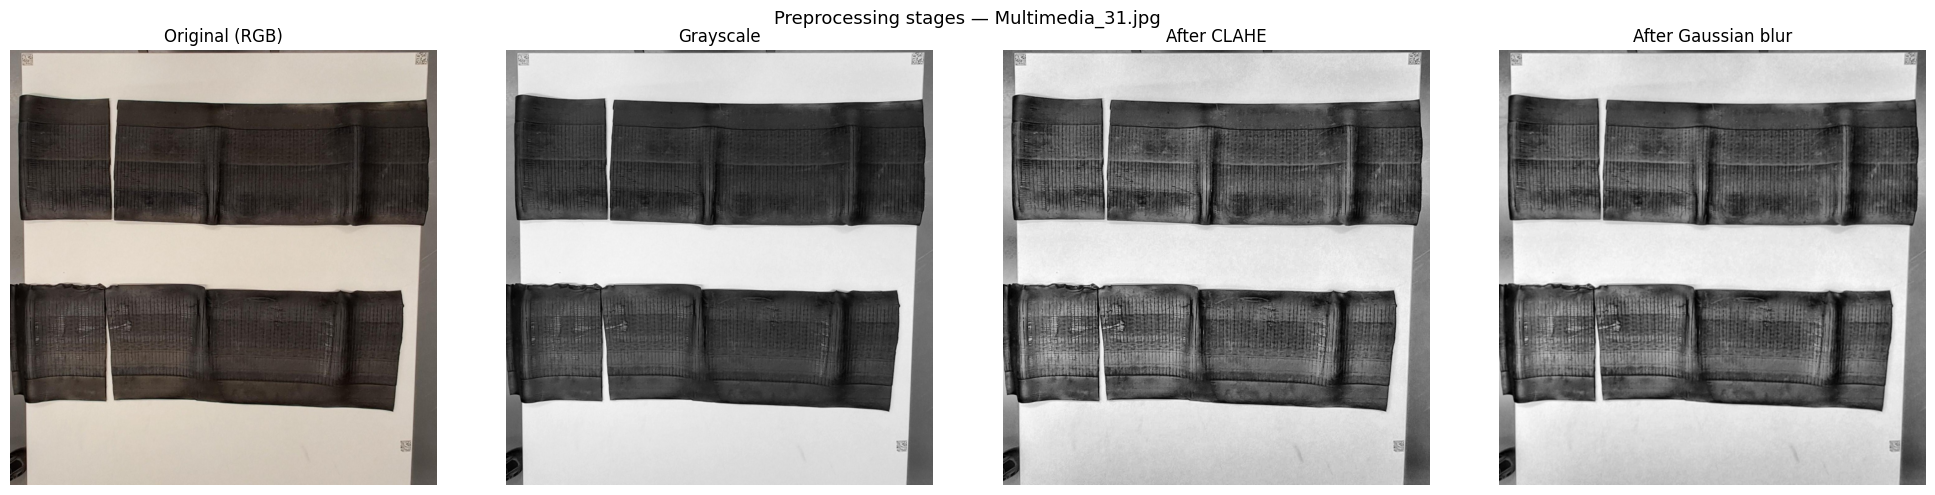

Figure saved.


In [13]:
# Change this to any image name in your dataset
EXAMPLE_IMAGE = image_paths[0]   # first image found

original, gray, clahe_img, blurred = preprocess_image(EXAMPLE_IMAGE)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"Preprocessing stages — {EXAMPLE_IMAGE.name}", fontsize=13)

stages = [
    (original_rgb, "Original (RGB)",  None),
    (gray,         "Grayscale",        "gray"),
    (clahe_img,    "After CLAHE",      "gray"),
    (blurred,      "After Gaussian blur", "gray"),
]

for ax, (img, title, cmap) in zip(axes, stages):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preprocessing_example.png", dpi=150)
plt.show()
print("Figure saved.")

## 5. Intensity histogram comparison

Compare the pixel intensity distributions before and after CLAHE to confirm the contrast enhancement.

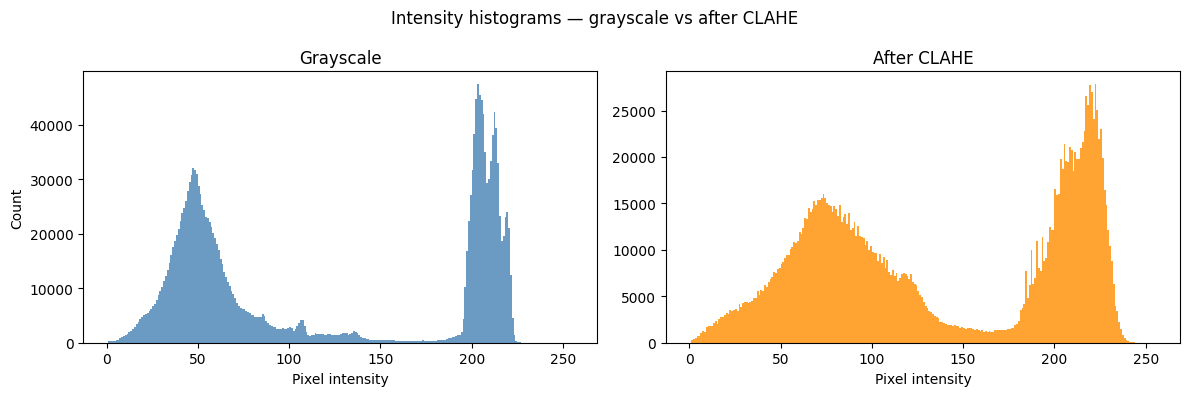

Histogram saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Intensity histograms — grayscale vs after CLAHE", fontsize=12)

axes[0].hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.8)
axes[0].set_title("Grayscale")
axes[0].set_xlabel("Pixel intensity")
axes[0].set_ylabel("Count")

axes[1].hist(clahe_img.ravel(), bins=256, range=(0, 256), color="darkorange", alpha=0.8)
axes[1].set_title("After CLAHE")
axes[1].set_xlabel("Pixel intensity")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histogram_comparison.png", dpi=150)
plt.show()
print("Histogram saved.")

## 6. Summary

| Step | Operation | Parameters |
|------|-----------|------------|
| 1a | Grayscale conversion | `cv2.COLOR_BGR2GRAY` |
| 1b | CLAHE | `clipLimit=2.0`, `tileGridSize=(8,8)` |
| 1c | Gaussian blur | `kernel=(5,5)`, `sigma=0` |

**Output folder:** `outputs/01_preprocessed/`  
**Next notebook:** `02_qr_homography.ipynb` — QR detection and perspective rectification